# Model Performance and Plots

This notebook covers:
1. Loading true and synthetic datasets
2. Ensemble vs manual metrics
3. Disagreement tables
4. Target-level confusion matrices and ROC curves
5. Time-series bad-flag diagnostics
6. Time-series-specific overall-model evaluation (calibration, error clustering, detection lag, and seasonal robustness)

All repeated plotting logic is consolidated into reusable functions.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, brier_score_loss

from config import PREDICTION_THRESHOLDS
from io_utils import load_qc_csvs
from prediction_comparison import load_and_predict, compare_predictions, format_metrics_table

sns.set_theme(style="whitegrid")

DATA_ROOT = Path("data")
TEST_MONTHS = ["2026-01", "2026-02"]
# TEST_MONTHS = ["2025-02", "2025-03", "2025-04", "2025-05", "2025-06", "2025-07",
#                "2025-08", "2025-09", "2025-10", "2025-11", "2025-12", "2026-01", "2026-02"]
TARGETS = ["Flag_GHI", "Flag_DNI", "Flag_DHI"]
TS_COL = "YYYY-MM-DD--HH:MM:SS"
PLOT_OUTPUT_DIR = Path("writeup")

## Helper Functions

Reusable helpers for loading, tabulation, and plotting to avoid duplicated code blocks.

In [2]:
def _save_current_plot(plot_name: str):
    PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", plot_name).strip("_.")
    safe_name = safe_name or "plot"
    out_path = PLOT_OUTPUT_DIR / f"{safe_name}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot: {out_path}")


def get_target_files_for_months(data_root: Path, target_months: list[str]) -> list[str]:
    pattern = re.compile(r"STW_(\d{4})-(\d{2})_QC\.csv$")
    target_set = set(target_months)
    selected = []

    for p in sorted(data_root.glob("**/*_QC.csv")):
        if "injected_error" in p.parts:
            continue
        m = pattern.match(p.name)
        if not m:
            continue
        year_month = f"{m.group(1)}-{m.group(2)}"
        if year_month in target_set:
            selected.append(str(p))

    return selected

def build_prediction_dataframe(raw_df: pd.DataFrame, comparison_results: dict, targets: list[str]) -> pd.DataFrame:
    df = raw_df.copy()
    df["_source_file"] = df.get("_source_file", None)
    df["_raw_ts"] = df[TS_COL]

    for target in targets:
        if target in comparison_results:
            pred_df = comparison_results[target][[f"{target}_predicted", "_raw_ts"]].copy()
            pred_df = pred_df.rename(columns={f"{target}_predicted": f"{target}_model"})
            df = df.merge(pred_df, on="_raw_ts", how="left")

    return df

def summarize_disagreements(all_results: pd.DataFrame) -> pd.DataFrame:
    if all_results.empty:
        return pd.DataFrame(columns=["target", "status", "count"])
    return (
        all_results.groupby(["target", "status"])
        .size()
        .reset_index(name="count")
        .sort_values(["target", "status"])
    )


def plot_target_confusion_matrices(all_results: pd.DataFrame, title: str, cmap: str = "Blues"):
    fig, axes = plt.subplots(1, len(TARGETS), figsize=(16, 4))
    for idx, target in enumerate(TARGETS):
        ax = axes[idx]
        target_data = all_results[all_results["target"] == target]
        if target_data.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(target)
            ax.axis("off")
            continue

        y_true = target_data["current_flag"].eq(99).astype(int)
        y_pred = target_data["predicted_flag"].eq(99).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        cm_norm = cm / max(cm.sum(), 1)

        sns.heatmap(
            cm,
            # cm_norm,
            annot=True,
            fmt="d",
            # fmt=".3f",
            cmap=cmap,
            cbar=False,
            xticklabels=["Pred GOOD", "Pred BAD"],
            yticklabels=["True GOOD", "True BAD"],
            ax=ax,
        )
        ax.set_title(target)
        ax.set_xlabel("Prediction")
        ax.set_ylabel("Truth")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    _save_current_plot(f"plot_target_confusion_matrices_{title}")
    plt.show()

def plot_disagreement_confusion_matrices(all_results: pd.DataFrame, title_suffix: str = "Regular Files"):
    """Render disagreement summary as confusion matrices using seaborn heatmaps."""
    fig, axes = plt.subplots(1, len(TARGETS), figsize=(16, 4))
    if len(TARGETS) == 1:
        axes = [axes]

    for ax, target in zip(axes, TARGETS):
        target_data = all_results[all_results["target"] == target]
        if target_data.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(target)
            ax.axis("off")
            continue

        y_true = target_data["current_flag"].eq(99).astype(int)
        y_pred = target_data["predicted_flag"].eq(99).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        cm_norm = cm / max(cm.sum(), 1)

        sns.heatmap(
            cm_norm,
            annot=True,
            fmt=".3f",
            cmap="RdYlGn",
            cbar=False,
            xticklabels=["Pred GOOD", "Pred BAD"],
            yticklabels=["True GOOD", "True BAD"],
            ax=ax,
            vmin=0,
            vmax=1,
        )
        ax.set_title(f"{target}")
        ax.set_xlabel("Prediction")
        ax.set_ylabel("Truth")

    fig.suptitle(f"Disagreement Confusion Matrices - {title_suffix}", y=1.02)
    plt.tight_layout()
    _save_current_plot(f"plot_disagreement_confusion_matrices_{title_suffix}")
    plt.show()


def plot_daily_bad_counts(df_regular: pd.DataFrame, all_results_regular: pd.DataFrame):
    if TS_COL not in df_regular.columns:
        print("Timestamp column not found in regular dataframe.")
        return

    df = df_regular.copy()
    df[TS_COL] = pd.to_datetime(df[TS_COL], errors="coerce")
    df["day"] = df[TS_COL].dt.floor("D")

    manual_rows = []
    for target in TARGETS:
        if target in df.columns:
            tmp = df[["day", target]].dropna().copy()
            tmp["bad_count"] = tmp[target].eq(99).astype(int)
            agg = tmp.groupby("day", as_index=False)["bad_count"].sum()
            agg["target"] = target
            manual_rows.append(agg)

    manual_daily = pd.concat(manual_rows, ignore_index=True) if manual_rows else pd.DataFrame(columns=["day", "bad_count", "target"])

    model_daily = pd.DataFrame(columns=["day", "bad_count", "target"])
    if not all_results_regular.empty:
        model_df = all_results_regular[["_raw_ts", "target", "predicted_flag"]].copy()
        model_df["day"] = pd.to_datetime(model_df["_raw_ts"], format="%Y-%m-%d--%H:%M:%S", errors="coerce").dt.floor("D")
        model_df["bad_count"] = model_df["predicted_flag"].eq(99).astype(int)
        model_daily = model_df.groupby(["day", "target"], as_index=False)["bad_count"].sum()

    all_days = pd.concat([
        manual_daily["day"] if not manual_daily.empty else pd.Series(dtype="datetime64[ns]"),
        model_daily["day"] if not model_daily.empty else pd.Series(dtype="datetime64[ns]"),
    ], ignore_index=True).dropna().drop_duplicates().sort_values()

    day_to_idx = {d: i for i, d in enumerate(all_days)}
    if not manual_daily.empty:
        manual_daily = manual_daily.copy()
        manual_daily["day_idx"] = manual_daily["day"].map(day_to_idx)
    if not model_daily.empty:
        model_daily = model_daily.copy()
        model_daily["day_idx"] = model_daily["day"].map(day_to_idx)

    if len(all_days) > 0:
        days_series = pd.Series(all_days).dropna()
        month_starts = days_series.groupby(days_series.dt.to_period("M")).min().sort_values()
        tick_pos = month_starts.map(day_to_idx).tolist()
        tick_labels = month_starts.dt.strftime("%Y-%m").tolist()
    else:
        tick_pos, tick_labels = [], []

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    for idx, target in enumerate(TARGETS):
        ax = axes[idx]
        
        manual_data = manual_daily[manual_daily["target"] == target] if not manual_daily.empty else pd.DataFrame()
        model_data = model_daily[model_daily["target"] == target] if not model_daily.empty else pd.DataFrame()

        if not manual_data.empty:
            ax.plot(manual_data["day_idx"], manual_data["bad_count"], marker="o", linestyle="-", label="Manual", color="blue", linewidth=2)
        else:
            ax.text(0.5, 0.5, "No manual flag data", ha="center", va="center", transform=ax.transAxes)

        if not model_data.empty:
            ax.plot(model_data["day_idx"], model_data["bad_count"], marker="s", linestyle="--", label="Model", color="red", linewidth=2)

        ax.set_title(f"{target} - Bad Flags per Day")
        ax.set_ylabel("Bad flag count")
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_labels, rotation=70, ha="right")

    axes[-1].set_xlabel("Month")
    plt.tight_layout()
    _save_current_plot("plot_daily_bad_counts")
    plt.show()


def plot_focus_window(day_raw: pd.DataFrame, day_points: pd.DataFrame, start_ts: str, title_suffix: str):
    """Plot irradiance with disagreement overlay and model prediction confidence.
    
    Maps physical irradiance (GHI, DNI, DHI) on primary y-axis and overlays 
    model BAD predictions as vertical lines on secondary y-axis.
    """
    if day_raw.empty:
        print(f"No raw data for {start_ts}.")
        return

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    irradiance_cols = ["GHI", "DNI", "DHI"]
    status_styles = {
        "model_only_bad": {"color": "red", "marker": "o", "label": "Model BAD / Manual GOOD"},
        "manual_only_bad": {"color": "blue", "marker": "x", "label": "Manual BAD / Model GOOD"},
        "match_bad": {"color": "green", "marker": "s", "label": "Model BAD / Manual BAD"},
    }

    for idx, irr_col in enumerate(irradiance_cols):
        ax = axes[idx]
        
        # Primary axis: irradiance data (left y-axis)
        ax.plot(day_raw[TS_COL], day_raw[irr_col], color="lightgray", alpha=0.7, linewidth=1, label="All data")

        target_key = f"Flag_{irr_col}"
        target_points = day_points[day_points["target"] == target_key]

        for status, style in status_styles.items():
            pts = target_points[target_points["status"] == status]
            if not pts.empty:
                ax.scatter(pts["ts"], pts["irradiance_value"], c=style["color"], marker=style["marker"], 
                          s=40, alpha=0.9, label=style["label"], zorder=5)

        ax.set_ylabel(f"{irr_col} (W/m^2)", color="black")
        ax.tick_params(axis="y", labelcolor="black")
        ax.set_title(f"{irr_col} - {title_suffix}")
        ax.grid(True, alpha=0.3)

        # Secondary axis: model prediction indicator (right y-axis)
        if False: # not target_points.empty:
            ax2 = ax.twinx()
            
            # Vertical lines where model predicts BAD
            model_bad_mask = target_points["predicted_flag"].eq(99)
            bad_times = target_points.loc[model_bad_mask, "ts"].unique()
            if len(bad_times) > 0:
                for t in bad_times:
                    ax2.axvline(t, color="darkorange", alpha=0.15, linestyle="--", linewidth=1)
            
            ax2.set_ylabel("Model Predictions", color="darkorange")
            ax2.tick_params(axis="y", labelcolor="darkorange")
            ax2.set_ylim(-0.1, 1.1)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels(["GOOD", "BAD"])
            
            # Combine legends
            if len(bad_times) > 0:
                from matplotlib.lines import Line2D
                model_line = Line2D([0], [0], color="darkorange", linestyle="--", linewidth=1.5, label="Model predicts BAD")
                lines1, labels1 = ax.get_legend_handles_labels()
                lines1.append(model_line)
                labels1.append("Model predicts BAD")
                ax.legend(handles=lines1, labels=labels1, loc="upper left", fontsize=8)
        else:
            ax.legend(loc="upper left", fontsize=12)

    axes[-1].set_xlabel("Datetime")
    plt.xticks(rotation=45)
    plt.tight_layout()
    _save_current_plot(f"plot_focus_window_{start_ts}_{title_suffix}")
    plt.show()

def _infer_prob_good_column(frame: pd.DataFrame, tgt: str) -> str | None:
    candidates = [
        f"{tgt}_prob",
        f"{tgt}_probability_good",
        f"{tgt}_prob_good",
        f"{tgt}_p_good",
        f"{tgt}_good_probability",
        "probability_good",
        "prob_good",
        "p_good",
    ]
    for col in candidates:
        if col in frame.columns:
            return col
    return None


def _infer_prob_bad_column(frame: pd.DataFrame, tgt: str) -> str | None:
    candidates = [
        f"{tgt}_probability_bad",
        f"{tgt}_prob_bad",
        f"{tgt}_p_bad",
        f"{tgt}_bad_probability",
        "probability_bad",
        "prob_bad",
        "p_bad",
    ]
    for col in candidates:
        if col in frame.columns:
            return col
    return None


def _get_p_bad_scores(frame: pd.DataFrame, tgt: str, pred_col: str = "predicted_flag") -> pd.Series:
    prob_bad_col = _infer_prob_bad_column(frame, tgt)
    if prob_bad_col is not None:
        return pd.to_numeric(frame[prob_bad_col], errors="coerce").clip(0.0, 1.0)

    prob_good_col = _infer_prob_good_column(frame, tgt)
    if prob_good_col is not None:
        p_good = pd.to_numeric(frame[prob_good_col], errors="coerce").clip(0.0, 1.0)
        return (1.0 - p_good).clip(0.0, 1.0)

    if pred_col in frame.columns:
        return frame[pred_col].eq(99).astype(float)

    return pd.Series(np.nan, index=frame.index, dtype=float)


def _get_bad_score_series(frame: pd.DataFrame) -> pd.Series:
    if "p_bad" in frame.columns:
        return pd.to_numeric(frame["p_bad"], errors="coerce").clip(0.0, 1.0)
    if "predicted_flag" in frame.columns:
        return frame["predicted_flag"].eq(99).astype(float)
    return pd.Series(np.nan, index=frame.index, dtype=float)


def _infer_steps_per_hour(ts_series: pd.Series) -> int:
    s = ts_series.dropna().sort_values()
    if len(s) < 2:
        return 1
    minutes = s.diff().dt.total_seconds().div(60.0).dropna()
    if minutes.empty:
        return 1
    median_minutes = float(minutes.median())
    if not np.isfinite(median_minutes) or median_minutes <= 0:
        return 1
    return max(int(round(60.0 / median_minutes)), 1)


def build_ts_eval_frame(results_by_target: dict[str, pd.DataFrame], targets: list[str]) -> pd.DataFrame:
    rows = []

    for target in targets:
        if target not in results_by_target:
            continue

        df_target = results_by_target[target].copy()
        curr_col = f"{target}_current"
        pred_col = f"{target}_predicted"
        if curr_col not in df_target.columns or pred_col not in df_target.columns or "_raw_ts" not in df_target.columns:
            continue

        valid_mask = np.isin(df_target[curr_col], [1, 11, 99])
        work = df_target.loc[valid_mask, ["_raw_ts", curr_col, pred_col]].copy()
        work = work.rename(columns={curr_col: "current_flag", pred_col: "predicted_flag"})

        source_slice = df_target.loc[work.index]
        work["p_bad"] = _get_p_bad_scores(source_slice, target, pred_col=pred_col)
        work["p_good"] = (1.0 - work["p_bad"]).clip(0.0, 1.0)
        work["target"] = target
        work["true_bad"] = work["current_flag"].eq(99).astype(int)
        work["pred_bad"] = work["predicted_flag"].eq(99).astype(int)
        work["error"] = (work["true_bad"] != work["pred_bad"]).astype(int)
        work["ts"] = pd.to_datetime(work["_raw_ts"], format="%Y-%m-%d--%H:%M:%S", errors="coerce")
        rows.append(work)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True).dropna(subset=["ts"]).copy()
    out["hour"] = out["ts"].dt.hour
    out["day"] = out["ts"].dt.floor("D")
    out["month"] = out["ts"].dt.to_period("M").astype(str)
    return out.sort_values(["target", "ts"]).reset_index(drop=True)

def compute_calibration_stats(ts_eval: pd.DataFrame, n_bins: int = 10) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Compute calibration metrics and reliability-curve points for BAD probabilities."""
    if ts_eval.empty:
        empty_metrics = pd.DataFrame(columns=["target", "n", "brier", "ece", "avg_p_bad", "base_bad_rate"])
        empty_curve = pd.DataFrame(columns=["target", "bin", "count", "p_bad_mean", "observed_bad_rate"])
        return empty_metrics, empty_curve

    metrics_rows = []
    curve_rows = []

    for target, g in ts_eval.groupby("target", dropna=False):
        df = g[["p_bad", "true_bad"]].copy()
        df["p_bad"] = pd.to_numeric(df["p_bad"], errors="coerce").clip(0.0, 1.0)
        df = df.dropna(subset=["p_bad", "true_bad"])
        n = len(df)
        if n == 0:
            continue

        brier = brier_score_loss(df["true_bad"].astype(int), df["p_bad"])
        base_bad_rate = float(df["true_bad"].mean())
        avg_p_bad = float(df["p_bad"].mean())

        bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
        df["bin"] = pd.cut(df["p_bad"], bins=bin_edges, include_lowest=True, labels=False)

        grouped = (
            df.groupby("bin", dropna=True)
            .agg(count=("true_bad", "size"), p_bad_mean=("p_bad", "mean"), observed_bad_rate=("true_bad", "mean"))
            .reset_index()
            .sort_values("bin")
        )

        if grouped.empty:
            ece = np.nan
        else:
            ece = float(
                np.average(
                    np.abs(grouped["p_bad_mean"] - grouped["observed_bad_rate"]),
                    weights=grouped["count"],
                )
            )

        metrics_rows.append(
            {
                "target": target,
                "n": n,
                "brier": brier,
                "ece": ece,
                "avg_p_bad": avg_p_bad,
                "base_bad_rate": base_bad_rate,
            }
        )

        grouped["target"] = target
        curve_rows.append(grouped[["target", "bin", "count", "p_bad_mean", "observed_bad_rate"]])

    metrics_df = pd.DataFrame(metrics_rows).sort_values("target") if metrics_rows else pd.DataFrame()
    curve_df = pd.concat(curve_rows, ignore_index=True) if curve_rows else pd.DataFrame()
    return metrics_df, curve_df


def plot_calibration_curves(calibration_curve_df: pd.DataFrame, title: str):
    plt.figure(figsize=(8, 6))

    if calibration_curve_df.empty:
        plt.text(0.5, 0.5, "No calibration data", ha="center", va="center")
        plt.title(title)
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        _save_current_plot(f"plot_calibration_curves_{title}")
        plt.show()
        return

    for target, g in calibration_curve_df.groupby("target"):
        plt.plot(g["p_bad_mean"], g["observed_bad_rate"], marker="o", linewidth=1.8, label=target)

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Perfect calibration")
    plt.xlabel("Predicted P(BAD)")
    plt.ylabel("Observed BAD rate")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    _save_current_plot(f"plot_calibration_curves_{title}")
    plt.show()


def compute_error_autocorrelation(ts_eval: pd.DataFrame, lag_hours: tuple[int, ...] = (1, 6, 24)) -> pd.DataFrame:
    """Compute error autocorrelation at selected hour lags per target."""
    if ts_eval.empty:
        return pd.DataFrame(columns=["target", "lag_hours", "autocorr", "n_pairs"])

    rows = []
    for target, g in ts_eval.groupby("target"):
        work = g.sort_values("ts").copy()
        if work.empty:
            continue

        steps_per_hour = _infer_steps_per_hour(work["ts"])
        err = work["error"].astype(float)

        for lag_h in lag_hours:
            shift_steps = max(int(round(lag_h * steps_per_hour)), 1)
            paired = pd.DataFrame({"e0": err, "e1": err.shift(shift_steps)}).dropna()
            if len(paired) < 2:
                corr = np.nan
            else:
                corr = float(paired["e0"].corr(paired["e1"]))
            rows.append({"target": target, "lag_hours": lag_h, "autocorr": corr, "n_pairs": len(paired)})

    return pd.DataFrame(rows).sort_values(["target", "lag_hours"]).reset_index(drop=True)


def plot_error_autocorrelation(autocorr_df: pd.DataFrame, title: str):
    plt.figure(figsize=(8, 5))

    if autocorr_df.empty:
        plt.text(0.5, 0.5, "No autocorrelation data", ha="center", va="center")
        plt.title(title)
        plt.tight_layout()
        _save_current_plot(f"plot_error_autocorrelation_{title}")
        plt.show()
        return

    sns.barplot(data=autocorr_df, x="lag_hours", y="autocorr", hue="target", errorbar=None)
    plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("Lag (hours)")
    plt.ylabel("Error autocorrelation")
    plt.title(title)
    plt.tight_layout()
    _save_current_plot(f"plot_error_autocorrelation_{title}")
    plt.show()


def plot_error_rate_heatmap(ts_eval: pd.DataFrame):
    """Show error rate by month and hour (aggregated across targets)."""
    if ts_eval.empty:
        print("No rows to plot error heatmap.")
        return

    work = ts_eval.copy()
    heat = (
        work.groupby(["month", "hour"], as_index=False)["error"]
        .mean()
        .pivot(index="month", columns="hour", values="error")
        .sort_index()
    )

    if heat.empty:
        print("No rows to plot error heatmap.")
        return

    plt.figure(figsize=(14, 4 + 0.35 * len(heat)))
    sns.heatmap(heat, cmap="YlOrRd", vmin=0, vmax=max(float(np.nanmax(heat.values)), 0.01), cbar_kws={"label": "Error rate"})
    plt.title("Error Rate by Month and Hour")
    plt.xlabel("Hour of day")
    plt.ylabel("Month")
    plt.tight_layout()
    _save_current_plot("plot_error_rate_heatmap")
    plt.show()


def compute_detection_lags(ts_eval: pd.DataFrame, max_lookahead_hours: int = 24) -> pd.DataFrame:
    """Compute delay from BAD onset to first model BAD prediction for each episode."""
    if ts_eval.empty:
        return pd.DataFrame(columns=["target", "episode_id", "onset_ts", "detected", "lag_hours", "steps_to_detect"])

    rows = []
    for target, g in ts_eval.groupby("target"):
        work = g.sort_values("ts").reset_index(drop=True).copy()
        if work.empty:
            continue

        true_bad = work["true_bad"].astype(int)
        pred_bad = work["pred_bad"].astype(int)
        steps_per_hour = _infer_steps_per_hour(work["ts"])
        max_steps = max(int(round(max_lookahead_hours * steps_per_hour)), 1)

        onset_mask = (true_bad == 1) & (true_bad.shift(1, fill_value=0) == 0)
        onset_indices = np.flatnonzero(onset_mask.to_numpy())

        for ep_id, i in enumerate(onset_indices, start=1):
            end = min(i + max_steps, len(work))
            pred_window = pred_bad.iloc[i:end]
            hit_pos = np.flatnonzero(pred_window.to_numpy() == 1)
            if len(hit_pos) > 0:
                steps_to_detect = int(hit_pos[0])
                lag_hours = steps_to_detect / steps_per_hour
                detected = True
            else:
                steps_to_detect = np.nan
                lag_hours = np.nan
                detected = False

            rows.append(
                {
                    "target": target,
                    "episode_id": ep_id,
                    "onset_ts": work.loc[i, "ts"],
                    "detected": detected,
                    "lag_hours": lag_hours,
                    "steps_to_detect": steps_to_detect,
                }
            )

    return pd.DataFrame(rows).sort_values(["target", "episode_id"]).reset_index(drop=True)


def summarize_detection_lags(lag_events_df: pd.DataFrame) -> pd.DataFrame:
    if lag_events_df.empty:
        return pd.DataFrame(columns=["target", "episodes", "detected_episodes", "detection_rate", "median_lag_h", "p90_lag_h"])

    rows = []
    for target, g in lag_events_df.groupby("target"):
        detected = g[g["detected"]]
        episodes = len(g)
        detected_episodes = len(detected)
        detection_rate = detected_episodes / episodes if episodes > 0 else np.nan
        median_lag_h = float(detected["lag_hours"].median()) if detected_episodes else np.nan
        p90_lag_h = float(detected["lag_hours"].quantile(0.9)) if detected_episodes else np.nan
        rows.append(
            {
                "target": target,
                "episodes": episodes,
                "detected_episodes": detected_episodes,
                "detection_rate": detection_rate,
                "median_lag_h": median_lag_h,
                "p90_lag_h": p90_lag_h,
            }
        )

    return pd.DataFrame(rows).sort_values("target").reset_index(drop=True)


def compute_bad_episode_early_recall(ts_eval: pd.DataFrame, horizon_hours: int = 2) -> pd.DataFrame:
    """Fraction of BAD episodes detected within the first horizon hours."""
    if ts_eval.empty:
        return pd.DataFrame(columns=["target", "episodes", "early_detected", "early_recall"])

    lag_events = compute_detection_lags(ts_eval, max_lookahead_hours=max(horizon_hours, 1))
    if lag_events.empty:
        return pd.DataFrame(columns=["target", "episodes", "early_detected", "early_recall"])

    rows = []
    for target, g in lag_events.groupby("target"):
        episodes = len(g)
        early_detected = int((g["lag_hours"] <= horizon_hours).fillna(False).sum())
        early_recall = early_detected / episodes if episodes > 0 else np.nan
        rows.append({"target": target, "episodes": episodes, "early_detected": early_detected, "early_recall": early_recall})

    return pd.DataFrame(rows).sort_values("target").reset_index(drop=True)


def plot_detection_lag_distribution(lag_events_df: pd.DataFrame):
    if lag_events_df.empty:
        print("No lag events to plot.")
        return

    detected = lag_events_df[lag_events_df["detected"]].copy()
    if detected.empty:
        print("No detected events to plot.")
        return

    plt.figure(figsize=(9, 5))
    sns.histplot(data=detected, x="lag_hours", hue="target", bins=20, element="step", stat="count", common_norm=False)
    plt.xlabel("Detection lag (hours)")
    plt.ylabel("Count")
    plt.title("Distribution of Detection Lags for BAD Episode Onsets")
    plt.tight_layout()
    _save_current_plot("plot_detection_lag_distribution")
    plt.show()


def plot_rolling_metrics(rolling_metrics_df: pd.DataFrame, metric: str = "rolling_f1"):
    if rolling_metrics_df.empty or metric not in rolling_metrics_df.columns:
        print(f"No data to plot for metric: {metric}")
        return

    plt.figure(figsize=(12, 5))
    for target, g in rolling_metrics_df.groupby("target"):
        plt.plot(g["ts"], g[metric], linewidth=1.2, alpha=0.9, label=target)

    plt.ylim(0, 1.05)
    plt.xlabel("Time")
    plt.ylabel(metric)
    plt.title(f"{metric} over Time")
    plt.grid(alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    _save_current_plot(f"plot_rolling_metrics_{metric}")
    plt.show()


def summarize_temporal_variability(rolling_metrics_df: pd.DataFrame, metric: str = "rolling_f1") -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if rolling_metrics_df.empty or metric not in rolling_metrics_df.columns:
        empty = pd.DataFrame()
        return empty, empty, empty

    monthly = (
        rolling_metrics_df.groupby(["target", "month"], as_index=False)[metric]
        .mean()
        .rename(columns={metric: "mean_metric"})
        .sort_values(["target", "month"])
    )

    hourly = (
        rolling_metrics_df.groupby(["target", "hour"], as_index=False)[metric]
        .mean()
        .rename(columns={metric: "mean_metric"})
        .sort_values(["target", "hour"])
    )

    variability = (
        rolling_metrics_df.groupby("target")[metric]
        .agg(mean_metric="mean", std_metric="std", min_metric="min", max_metric="max")
        .reset_index()
    )

    return monthly, hourly, variability

def compute_rolling_metrics(ts_eval: pd.DataFrame, window_hours: int = 24) -> pd.DataFrame:
    """Compute rolling F1/precision/recall over time per target (vectorized)."""
    if ts_eval.empty:
        return pd.DataFrame(columns=["target", "ts", "rolling_f1", "rolling_precision", "rolling_recall", "window_n"])

    rows = []
    for target, g in ts_eval.groupby("target"):
        work = g.sort_values("ts").copy()
        if work.empty:
            continue

        steps_per_hour = _infer_steps_per_hour(work["ts"])
        window_steps = max(int(round(window_hours * steps_per_hour)), 1)

        y_true = work["true_bad"].astype(int)
        y_pred = work["pred_bad"].astype(int)

        tp = (y_true.eq(1) & y_pred.eq(1)).astype(int)
        fp = (y_true.eq(0) & y_pred.eq(1)).astype(int)
        fn = (y_true.eq(1) & y_pred.eq(0)).astype(int)

        tp_roll = tp.rolling(window_steps, min_periods=1).sum()
        fp_roll = fp.rolling(window_steps, min_periods=1).sum()
        fn_roll = fn.rolling(window_steps, min_periods=1).sum()

        with np.errstate(divide="ignore", invalid="ignore"):
            precision = (tp_roll / (tp_roll + fp_roll)).fillna(0.0)
            recall = (tp_roll / (tp_roll + fn_roll)).fillna(0.0)
            f1 = (2.0 * precision * recall / (precision + recall)).fillna(0.0)

        out = pd.DataFrame(
            {
                "target": target,
                "ts": pd.to_datetime(work["ts"]),
                "rolling_f1": f1.to_numpy(),
                "rolling_precision": precision.to_numpy(),
                "rolling_recall": recall.to_numpy(),
                "window_n": pd.Series(np.ones(len(work), dtype=int)).rolling(window_steps, min_periods=1).sum().astype(int).to_numpy(),
            }
        )
        out["hour"] = out["ts"].dt.hour
        out["month"] = out["ts"].dt.to_period("M").astype(str)
        rows.append(out)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def build_disagreement_table(results_by_target: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Build disagreement table with calibrated BAD probability when available."""
    rows = []
    for target, df in results_by_target.items():
        pred_col = f"{target}_predicted"
        curr_col = f"{target}_current"
        if pred_col not in df.columns or curr_col not in df.columns:
            continue

        irradiance_col = target.replace("Flag_", "")
        cols_to_keep = ["_source_file", "_raw_ts", pred_col, curr_col]
        if irradiance_col in df.columns:
            cols_to_keep.append(irradiance_col)

        tmp = df[cols_to_keep].copy()
        rename_map = {pred_col: "predicted_flag", curr_col: "current_flag"}
        if irradiance_col in tmp.columns:
            rename_map[irradiance_col] = "irradiance_value"
        tmp = tmp.rename(columns=rename_map)
        if "irradiance_value" not in tmp.columns:
            tmp["irradiance_value"] = np.nan

        tmp["p_bad"] = _get_p_bad_scores(df.loc[tmp.index], target, pred_col=pred_col)

        tmp["target"] = target
        tmp["pred_bad"] = tmp["predicted_flag"].eq(99)
        tmp["curr_bad"] = tmp["current_flag"].eq(99)
        tmp["status"] = np.select(
            [
                (~tmp["pred_bad"]) & (~tmp["curr_bad"]),
                (tmp["pred_bad"]) & (tmp["curr_bad"]),
                (tmp["pred_bad"]) & (~tmp["curr_bad"]),
                (~tmp["pred_bad"]) & (tmp["curr_bad"]),
            ],
            ["match_good", "match_bad", "model_only_bad", "manual_only_bad"],
            default="unknown",
        )
        rows.append(tmp)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out["ts"] = pd.to_datetime(out["_raw_ts"], format="%Y-%m-%d--%H:%M:%S", errors="coerce")
    return out


def plot_target_roc_curves(all_results: pd.DataFrame, title: str):
    """Plot ROC using probability-like BAD scores (falls back to hard labels if unavailable)."""
    plt.figure(figsize=(7, 6))
    plotted_any = False

    colors = sns.color_palette("tab10", n_colors=len(TARGETS))
    for target, color in zip(TARGETS, colors):
        target_df = all_results[all_results["target"] == target]
        if target_df.empty:
            continue

        y_true = target_df["current_flag"].eq(99).astype(int)
        if y_true.nunique() < 2:
            continue

        y_score = _get_bad_score_series(target_df)

        valid = y_score.notna() & y_true.notna()
        y_true_v = y_true.loc[valid]
        y_score_v = y_score.loc[valid].clip(0.0, 1.0)
        if len(y_true_v) == 0:
            continue

        fpr, tpr, _ = roc_curve(y_true_v, y_score_v)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, color=color, label=f"{target} (AUC={roc_auc:.3f})")
        plotted_any = True

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.grid(alpha=0.3)
    if plotted_any:
        plt.legend(loc="lower right")
    else:
        plt.text(0.5, 0.45, "ROC unavailable (single class only)", ha="center", va="center")
    plt.tight_layout()
    _save_current_plot(f"plot_target_roc_curves_{title}")
    plt.show()


def plot_target_pr_curves(all_results: pd.DataFrame, title: str):
    """Plot PR curves using probability-like BAD scores (better for imbalance)."""
    plt.figure(figsize=(7, 6))
    plotted_any = False

    colors = sns.color_palette("tab10", n_colors=len(TARGETS))
    for target, color in zip(TARGETS, colors):
        target_df = all_results[all_results["target"] == target]
        if target_df.empty:
            continue

        y_true = target_df["current_flag"].eq(99).astype(int)
        if y_true.nunique() < 2:
            continue

        y_score = _get_bad_score_series(target_df)

        valid = y_score.notna() & y_true.notna()
        y_true_v = y_true.loc[valid]
        y_score_v = y_score.loc[valid].clip(0.0, 1.0)
        if len(y_true_v) == 0:
            continue

        precision, recall, _ = precision_recall_curve(y_true_v, y_score_v)
        ap = average_precision_score(y_true_v, y_score_v)
        plt.plot(recall, precision, lw=2, color=color, label=f"{target} (AP={ap:.3f})")
        plotted_any = True

    baseline_pos_rate = all_results["current_flag"].eq(99).sum() / len(all_results) if len(all_results) > 0 else 0
    plt.axhline(baseline_pos_rate, linestyle="--", color="gray", lw=1, label=f"Baseline ({baseline_pos_rate:.3f})")
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.xlabel("Recall (True Positive Rate)")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid(alpha=0.3)
    if plotted_any:
        plt.legend(loc="best")
    else:
        plt.text(0.5, 0.45, "PR curves unavailable (single class only)", ha="center", va="center")
    plt.tight_layout()
    _save_current_plot(f"plot_target_pr_curves_{title}")
    plt.show()

    
def plot_f1_vs_threshold(
    all_results_left: pd.DataFrame,
    all_results_right: pd.DataFrame,
    left_title: str = "Regular Files",
    right_title: str = "Injected Error Files",
    thresholds: np.ndarray | None = None,
):
    """Compare F1 vs threshold curves side by side for two datasets."""
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 201)

    def _plot_panel(ax, all_results: pd.DataFrame, panel_title: str):
        if all_results.empty:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center")
            ax.set_title(panel_title)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1.05)
            ax.grid(alpha=0.3)
            return

        plotted_any = False
        colors = sns.color_palette("tab10", n_colors=len(TARGETS))

        for target, color in zip(TARGETS, colors):
            target_df = all_results[all_results["target"] == target].copy()
            if target_df.empty:
                continue

            y_true = target_df["current_flag"].eq(99).astype(int)
            if y_true.nunique() < 2:
                continue

            y_score = _get_bad_score_series(target_df)

            valid = y_score.notna() & y_true.notna()
            y_true = y_true.loc[valid]
            y_score = y_score.loc[valid]
            if len(y_true) == 0:
                continue

            f1_vals = []
            for thr in thresholds:
                y_pred = (y_score >= thr).astype(int)
                f1_vals.append(f1_score(y_true, y_pred, zero_division=0))

            best_idx = int(np.argmax(f1_vals))
            best_thr = float(thresholds[best_idx])
            best_f1 = float(f1_vals[best_idx])

            ax.plot(thresholds, f1_vals, color=color, lw=2, label=f"{target} ({best_f1:.3f} @ {best_thr:.3f})")
            ax.scatter([best_thr], [best_f1], color=color, s=28, zorder=5)
            plotted_any = True

        ax.set_title(panel_title)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Decision threshold on P(BAD)")
        ax.set_ylabel("F1 score")
        ax.grid(alpha=0.3)
        if plotted_any:
            ax.legend(loc="best", fontsize=9)
        else:
            ax.text(0.5, 0.5, "Insufficient class diversity", ha="center", va="center")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    _plot_panel(axes[0], all_results_left, f"F1 vs Threshold - {left_title}")
    _plot_panel(axes[1], all_results_right, f"F1 vs Threshold - {right_title}")
    fig.suptitle("F1 vs Decision Threshold Comparison", y=1.02)
    plt.tight_layout()
    _save_current_plot(f"plot_f1_vs_threshold{left_title}_{right_title}")
    plt.show()


def _aggregate_bad_counts(df_raw: pd.DataFrame, all_results: pd.DataFrame, timeframe: str) -> pd.DataFrame:
    if timeframe not in {"hour", "month"}:
        raise ValueError(f"Unsupported timeframe: {timeframe}")

    # --- Manual counts per target ---
    manual_rows = []
    if not df_raw.empty and TS_COL in df_raw.columns:
        raw = df_raw.copy()
        raw["_ts"] = pd.to_datetime(raw[TS_COL], errors="coerce")
        raw = raw.dropna(subset=["_ts"])

        if timeframe == "hour":
            raw["_key"] = raw["_ts"].dt.hour
        else:
            raw["_key"] = raw["_ts"].dt.to_period("M").astype(str)

        for target in TARGETS:
            if target in raw.columns:
                bad = pd.to_numeric(raw[target], errors="coerce").eq(99).astype(int)
                s = bad.groupby(raw["_key"]).sum()
                manual_rows.append(
                    pd.DataFrame(
                        {"target": target, "time_key": s.index.astype(str), "manual_bad_count": s.values}
                    )
                )

    manual_df = (
        pd.concat(manual_rows, ignore_index=True)
        if manual_rows
        else pd.DataFrame(columns=["target", "time_key", "manual_bad_count"])
    )

    # --- Model counts per target ---
    model_df = pd.DataFrame(columns=["target", "time_key", "model_bad_count"])
    if not all_results.empty and {"_raw_ts", "predicted_flag", "target"}.issubset(all_results.columns):
        model = all_results[["_raw_ts", "predicted_flag", "target"]].copy()
        model["_ts"] = pd.to_datetime(model["_raw_ts"], format="%Y-%m-%d--%H:%M:%S", errors="coerce")
        model = model.dropna(subset=["_ts"])

        if timeframe == "hour":
            model["_key"] = model["_ts"].dt.hour
        else:
            model["_key"] = model["_ts"].dt.to_period("M").astype(str)

        agg = (
            model.assign(_is_bad=model["predicted_flag"].eq(99).astype(int))
            .groupby(["target", "_key"], as_index=False)["_is_bad"]
            .sum()
            .rename(columns={"_key": "time_key", "_is_bad": "model_bad_count"})
        )
        agg["time_key"] = agg["time_key"].astype(str)
        model_df = agg

    # --- Build complete grid (all targets x all keys) ---
    if timeframe == "hour":
        keys = [str(h) for h in range(24)]
    else:
        key_set = set(manual_df["time_key"].tolist()) | set(model_df["time_key"].tolist())
        keys = sorted(key_set)

    grid = pd.MultiIndex.from_product([TARGETS, keys], names=["target", "time_key"]).to_frame(index=False)

    out = (
        grid.merge(manual_df, on=["target", "time_key"], how="left")
        .merge(model_df, on=["target", "time_key"], how="left")
        .fillna(0)
    )
    out["manual_bad_count"] = out["manual_bad_count"].astype(float)
    out["model_bad_count"] = out["model_bad_count"].astype(float)
    return out


def _plot_bad_counts_comparison(
    df_injected: pd.DataFrame,
    all_results_injected: pd.DataFrame,
    timeframe: str,
):
    data = _aggregate_bad_counts(df_injected, all_results_injected, timeframe=timeframe).copy()
    if data.empty:
        print("No injected data available to plot.")
        return

    n_targets = len(TARGETS)
    fig, axes = plt.subplots(n_targets, 1, figsize=(14, 3.5 * n_targets), sharex=True)
    if n_targets == 1:
        axes = [axes]

    # X-axis setup
    if timeframe == "hour":
        x_ticks = np.arange(24, dtype=int)
        x_labels = [str(x) for x in x_ticks]
    else:
        all_keys = sorted(data["time_key"].astype(str).unique())
        x_ticks = np.arange(len(all_keys), dtype=int)
        key_to_x = {k: i for i, k in enumerate(all_keys)}

    for ax, target in zip(axes, TARGETS):
        tdf = data[data["target"] == target].copy()
        if tdf.empty:
            ax.text(0.5, 0.5, f"No data for {target}", ha="center", va="center", transform=ax.transAxes)
            ax.grid(True, alpha=0.3)
            continue

        if timeframe == "hour":
            tdf["x"] = pd.to_numeric(tdf["time_key"], errors="coerce").astype("Int64")
            tdf = tdf.dropna(subset=["x"]).sort_values("x")
            x_plot = tdf["x"].astype(int).to_numpy()
        else:
            tdf["_period"] = pd.PeriodIndex(tdf["time_key"].astype(str), freq="M")
            tdf = tdf.sort_values("_period")
            x_plot = tdf["time_key"].map(key_to_x).to_numpy()

        ax.plot(x_plot, tdf["manual_bad_count"], marker="o", linewidth=2, color="blue", label="Manual BAD")
        ax.plot(x_plot, tdf["model_bad_count"], marker="s", linewidth=2, linestyle="--", color="red", label="Model BAD")
        ax.set_ylabel("BAD count")
        ax.set_title(target.replace("Flag_", ""))
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper left")

    if timeframe == "hour":
        axes[-1].set_xlabel("Hour of day")
        axes[-1].set_xticks(x_ticks)
        axes[-1].set_xticklabels(x_labels)
        axes[-1].set_xlim(-0.5, 23.5)
        fig.suptitle("Hourly BAD Counts by Target - Injected Only", y=1.02)
        save_name = "plot_hourly_bad_counts_injected_multiplot"
    else:
        axes[-1].set_xlabel("Month")
        axes[-1].set_xticks(x_ticks)
        axes[-1].set_xticklabels(all_keys, rotation=45, ha="right")
        fig.suptitle("Monthly BAD Counts by Target - Injected Only", y=1.02)
        save_name = "plot_monthly_bad_counts_injected_multiplot"

    plt.tight_layout()
    _save_current_plot(save_name)
    plt.show()


def plot_hourly_bad_counts_comparison(df_injected: pd.DataFrame, all_results_injected: pd.DataFrame):
    _plot_bad_counts_comparison(df_injected, all_results_injected, timeframe="hour")


def plot_monthly_bad_counts_comparison(df_injected: pd.DataFrame, all_results_injected: pd.DataFrame):
    _plot_bad_counts_comparison(df_injected, all_results_injected, timeframe="month")

def align_dataframes_by_timestamp(df_regular: pd.DataFrame, df_injected: pd.DataFrame, ts_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Report timestamp overlap without filtering either dataset."""
    if df_regular.empty or df_injected.empty:
        return df_regular.copy(), df_injected.copy()

    regular_ts = pd.to_datetime(df_regular[ts_col], errors="coerce")
    injected_ts = pd.to_datetime(df_injected[ts_col], errors="coerce")

    ts_regular = set(regular_ts.dropna().unique())
    ts_injected = set(injected_ts.dropna().unique())
    common_ts = ts_regular & ts_injected

    print(
        f"Regular timestamps: {len(ts_regular)}, Injected: {len(ts_injected)}, "
        f"Common: {len(common_ts)}"
    )
    print(f"Regular shape: {df_regular.shape}, Injected shape: {df_injected.shape}")
    print("Datasets are kept separate; timestamp overlap is reported for diagnostics only.")

    return df_regular.reset_index(drop=True).copy(), df_injected.reset_index(drop=True).copy()


def find_optimal_threshold(all_results: pd.DataFrame, target: str, metric: str = "f1") -> tuple[float, float]:
    """Find the best BAD-class threshold using probability scores when available."""
    target_df = all_results[all_results["target"] == target].copy()
    if target_df.empty:
        return np.nan, np.nan

    y_true = target_df["current_flag"].eq(99).astype(int)
    y_score = _get_bad_score_series(target_df)

    valid = y_true.notna() & y_score.notna()
    y_true = y_true.loc[valid]
    y_score = y_score.loc[valid]

    if len(y_true) == 0 or y_true.nunique() < 2:
        return np.nan, np.nan

    best_threshold, best_value = np.nan, -np.inf

    for threshold in np.linspace(0.0, 1.0, 201):
        y_pred = (y_score >= threshold).astype(int)

        if metric == "f1":
            value = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "precision":
            value = precision_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            value = recall_score(y_true, y_pred, zero_division=0)
        elif metric == "f2":
            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            value = (5 * precision * recall) / (4 * precision + recall) if (4 * precision + recall) > 0 else 0.0
        else:
            raise ValueError(f"Unsupported metric: {metric}")

        if value > best_value:
            best_value = float(value)
            best_threshold = float(threshold)

    return best_threshold, best_value

## Load Data and Predictions

In [3]:
regular_files = get_target_files_for_months(DATA_ROOT, TEST_MONTHS)
print(f"Selected {len(regular_files)} regular files for {TEST_MONTHS}")
for fp in regular_files:
    print(" -", fp)

if not regular_files:
    raise ValueError("No regular files selected; check TEST_MONTHS.")

raw_regular = load_qc_csvs(regular_files, header_rows_skip=43, ts_col=TS_COL)
comparison_results_regular = load_and_predict(regular_files, TARGETS)
df_regular = build_prediction_dataframe(raw_regular, comparison_results_regular, TARGETS)

injected_files = sorted(DATA_ROOT.glob("injected_error/*_errored.csv"))
injected_file_paths = [str(f) for f in injected_files]
print(f"Selected {len(injected_file_paths)} injected files")
for fp in injected_file_paths:
    print(" -", fp)

if injected_file_paths:
    raw_injected = load_qc_csvs(injected_file_paths, header_rows_skip=43, ts_col=TS_COL)
    comparison_results_injected = load_and_predict(injected_file_paths, TARGETS)
    df_injected = build_prediction_dataframe(raw_injected, comparison_results_injected, TARGETS)
else:
    raw_injected = pd.DataFrame()
    comparison_results_injected = {}
    df_injected = pd.DataFrame()

print(f"Regular dataframe shape: {df_regular.shape}")
print(f"Injected dataframe shape: {df_injected.shape}")

# ===== TIMESTAMP OVERLAP DIAGNOSTIC (NO FILTERING) =====
print("\n=== Timestamp Overlap Diagnostic (datasets kept separate) ===")
df_regular, df_injected = align_dataframes_by_timestamp(df_regular, df_injected, TS_COL)
print(f"Post-check shapes - Regular: {df_regular.shape}, Injected: {df_injected.shape}")

if TS_COL in df_injected.columns and not df_injected.empty:
    injected_months = (
        pd.to_datetime(df_injected[TS_COL], errors="coerce")
        .dt.to_period("M")
        .astype(str)
    )
    injected_months = sorted(m for m in injected_months.dropna().unique() if m != "NaT")
    print(f"Injected months loaded: {injected_months}")

Selected 2 regular files for ['2026-01', '2026-02']
 - data\STW_2026\STW_2026-01_QC.csv
 - data\STW_2026\STW_2026-02_QC.csv

Loading 2 file(s)...
Loaded 84960 samples from 2 file(s)
Adding features...

--- Predicting Flag_GHI ---
Model loaded from models\model_Flag_GHI.pkl (type: RNN, version: 1.0)
Predicting 84960 samples...
Using decision threshold for Flag_GHI: 0.500
Using RF blend weight for Flag_GHI: 0.700
  Predicted: 84891 GOOD (99.9%), 69 BAD (0.1%)
  Mean confidence (P(GOOD)): 0.998

--- Predicting Flag_DNI ---
Model loaded from models\model_Flag_DNI.pkl (type: RNN, version: 1.0)
Predicting 84960 samples...
Using decision threshold for Flag_DNI: 0.500
Using RF blend weight for Flag_DNI: 0.700
  Predicted: 84893 GOOD (99.9%), 67 BAD (0.1%)
  Mean confidence (P(GOOD)): 0.983

--- Predicting Flag_DHI ---
Model loaded from models\model_Flag_DHI.pkl (type: RNN, version: 1.0)
Predicting 84960 samples...
Using decision threshold for Flag_DHI: 0.500
Using RF blend weight for Flag_DHI:

## Ensemble Metrics (Model vs Manual)

In [4]:
comparison_metrics_regular = compare_predictions(comparison_results_regular, TARGETS)
print("=== REGULAR FILES ===")
print(format_metrics_table(comparison_metrics_regular, TARGETS))
display(pd.DataFrame(comparison_metrics_regular).T)

if comparison_results_injected:
    comparison_metrics_injected = compare_predictions(comparison_results_injected, TARGETS)
    print("\n=== INJECTED ERROR FILES ===")
    print(format_metrics_table(comparison_metrics_injected, TARGETS))
    display(pd.DataFrame(comparison_metrics_injected).T)
else:
    print("\nNo injected results available.")

=== REGULAR FILES ===

                              PREDICTION COMPARISON RESULTS                               

Feature         Samples      Agreement            Accuracy     Precision    Recall       F1          
------------------------------------------------------------------------------------------
Flag_GHI        84835        84810/84835 (100.0%) 0.9997       0.9833       0.7108       0.8252      
Flag_DNI        84848        84777/84848 (99.9%)  0.9992       0.9242       0.4803       0.6321      
Flag_DHI        84725        84709/84725 (100.0%) 0.9998       1.0000       0.6667       0.8000      



,n_samples,n_agree,n_disagree,pct_agree,accuracy,precision,recall,f1
Flag_GHI,84835.0,84810.0,25.0,99.970531,0.999705,0.983333,0.710843,0.825175
Flag_DNI,84848.0,84777.0,71.0,99.916321,0.999163,0.924242,0.480315,0.632124
Flag_DHI,84725.0,84709.0,16.0,99.981115,0.999811,1.000000,0.666667,0.800000



=== INJECTED ERROR FILES ===

                              PREDICTION COMPARISON RESULTS                               

Feature         Samples      Agreement            Accuracy     Precision    Recall       F1          
------------------------------------------------------------------------------------------
Flag_GHI        458658       457840/458658 (99.8%) 0.9982       0.9339       0.8281       0.8778      
Flag_DNI        427156       425919/427156 (99.7%) 0.9971       0.8245       0.6079       0.6998      
Flag_DHI        428560       427401/428560 (99.7%) 0.9973       0.8503       0.6669       0.7475      



,n_samples,n_agree,n_disagree,pct_agree,accuracy,precision,recall,f1
Flag_GHI,458658.0,457840.0,818.0,99.821654,0.998217,0.933884,0.828072,0.877801
Flag_DNI,427156.0,425919.0,1237.0,99.710410,0.997104,0.824471,0.607926,0.699830
Flag_DHI,428560.0,427401.0,1159.0,99.729559,0.997296,0.850347,0.666926,0.747550


## Disagreement Tables

In [5]:
all_results_regular = build_disagreement_table(comparison_results_regular)
all_results_injected = build_disagreement_table(comparison_results_injected) if comparison_results_injected else pd.DataFrame()

summary_regular = summarize_disagreements(all_results_regular)
summary_injected = summarize_disagreements(all_results_injected)

print("=== REGULAR DISAGREEMENT SUMMARY ===")
display(summary_regular.head())
display(all_results_regular[all_results_regular["status"].isin(["model_only_bad", "manual_only_bad"])].head())

if not all_results_injected.empty:
    print("\n=== INJECTED DISAGREEMENT SUMMARY ===")
    display(summary_injected.head())
    display(all_results_injected[all_results_injected["status"].isin(["model_only_bad", "manual_only_bad"])].head())

=== REGULAR DISAGREEMENT SUMMARY ===


,target,status,count
0,Flag_DHI,manual_only_bad,16
1,Flag_DHI,match_bad,32
2,Flag_DHI,match_good,84873
3,Flag_DHI,model_only_bad,39
4,Flag_DNI,manual_only_bad,66


,_source_file,_raw_ts,predicted_flag,current_flag,irradiance_value,p_bad,target,pred_bad,curr_bad,status,ts
2100,data\STW_2026\STW_2026-01_QC.csv,2026-01-02--11:01:00,1,99.0,57.81,0.292481,Flag_GHI,False,True,manual_only_bad,2026-01-02 11:01:00
2102,data\STW_2026\STW_2026-01_QC.csv,2026-01-02--11:03:00,1,99.0,51.21,0.101729,Flag_GHI,False,True,manual_only_bad,2026-01-02 11:03:00
10735,data\STW_2026\STW_2026-01_QC.csv,2026-01-08--10:56:00,1,99.0,83.88,0.247292,Flag_GHI,False,True,manual_only_bad,2026-01-08 10:56:00
27977,data\STW_2026\STW_2026-01_QC.csv,2026-01-20--10:18:00,1,99.0,267.79,0.157211,Flag_GHI,False,True,manual_only_bad,2026-01-20 10:18:00
36657,data\STW_2026\STW_2026-01_QC.csv,2026-01-26--10:58:00,1,99.0,129.42,0.316579,Flag_GHI,False,True,manual_only_bad,2026-01-26 10:58:00



=== INJECTED DISAGREEMENT SUMMARY ===


,target,status,count
0,Flag_DHI,manual_only_bad,857
1,Flag_DHI,match_bad,1716
2,Flag_DHI,match_good,518238
3,Flag_DHI,model_only_bad,469
4,Flag_DNI,manual_only_bad,930


,_source_file,_raw_ts,predicted_flag,current_flag,irradiance_value,p_bad,target,pred_bad,curr_bad,status,ts
754,data\injected_error\STW_2025-02_QC_errored.csv,2025-02-01--12:35:00,99,12.0,591.15,0.915802,Flag_GHI,True,False,model_only_bad,2025-02-01 12:35:00
755,data\injected_error\STW_2025-02_QC_errored.csv,2025-02-01--12:36:00,99,12.0,568.95,0.915802,Flag_GHI,True,False,model_only_bad,2025-02-01 12:36:00
756,data\injected_error\STW_2025-02_QC_errored.csv,2025-02-01--12:37:00,99,12.0,547.25,0.915802,Flag_GHI,True,False,model_only_bad,2025-02-01 12:37:00
757,data\injected_error\STW_2025-02_QC_errored.csv,2025-02-01--12:38:00,99,12.0,506.28,0.915803,Flag_GHI,True,False,model_only_bad,2025-02-01 12:38:00
2172,data\injected_error\STW_2025-02_QC_errored.csv,2025-02-02--12:13:00,99,11.0,175.04,0.644919,Flag_GHI,True,False,model_only_bad,2025-02-02 12:13:00


In [6]:
# # ===== DYNAMIC THRESHOLD ANALYSIS =====
# print("\n=== DYNAMIC THRESHOLD TUNING (F1 and F2 optimization) ===")
# print("F1 = balanced precision-recall metric")
# print("F2 = recall-weighted metric (penalizes missed anomalies more heavily)\n")

# threshold_results = []
# for target in TARGETS:
#     opt_thresh_f1, max_f1 = find_optimal_threshold(all_results_injected, target, metric="f1")
#     opt_thresh_f2, max_f2 = find_optimal_threshold(all_results_injected, target, metric="f2")
#     opt_thresh_rec, max_rec = find_optimal_threshold(all_results_injected, target, metric="recall")
    
#     threshold_results.append({
#         "Target": target,
#         "F1_Optimal_Threshold": float(opt_thresh_f1) if pd.notna(opt_thresh_f1) else np.nan,
#         "F1_Max_Score": float(max_f1) if pd.notna(max_f1) else np.nan,
#         "F2_Optimal_Threshold": float(opt_thresh_f2) if pd.notna(opt_thresh_f2) else np.nan,
#         "F2_Max_Score": float(max_f2) if pd.notna(max_f2) else np.nan,
#         "Recall_Optimal_Threshold": float(opt_thresh_rec) if pd.notna(opt_thresh_rec) else np.nan,
#         "Max_Recall": float(max_rec) if pd.notna(max_rec) else np.nan,
#     })

# threshold_df = pd.DataFrame(threshold_results)
# display(threshold_df)
# print("\nRecommendation: Use F2 threshold to prioritize catching missed anomalies (high recall).")
# plot_f1_vs_threshold(
#     all_results_regular,
#     all_results_injected,
#     left_title="Regular Files",
#     right_title="Injected Error Files",
# )


## Target-Level Confusion Matrices and ROC

Saved plot: writeup\plot_target_confusion_matrices_Confusion_Matrices_-_Regular_Files.png


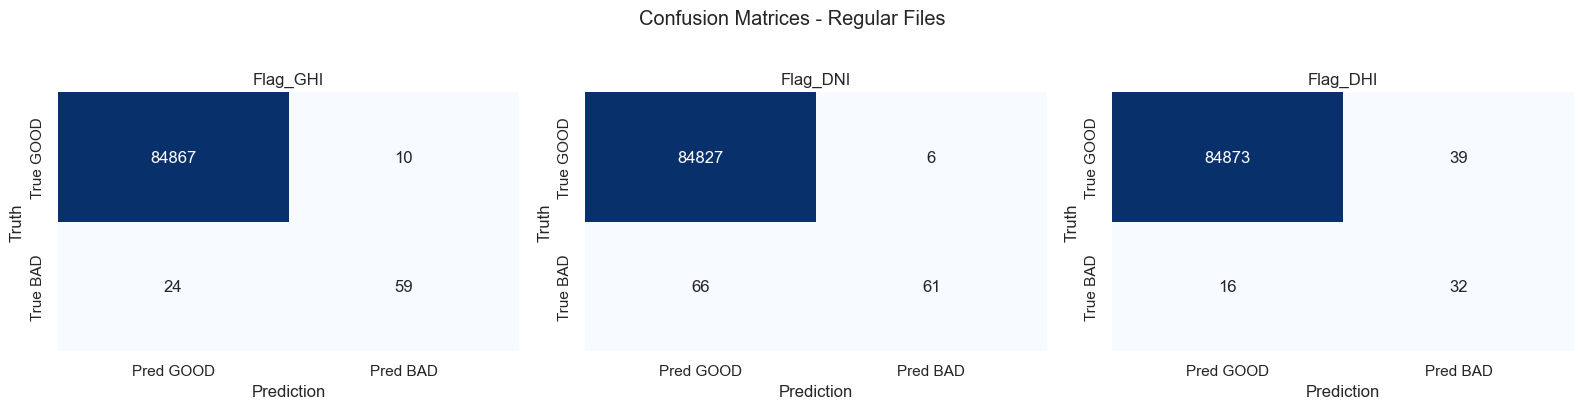

Saved plot: writeup\plot_target_roc_curves_ROC_Curves_-_Regular_Files.png


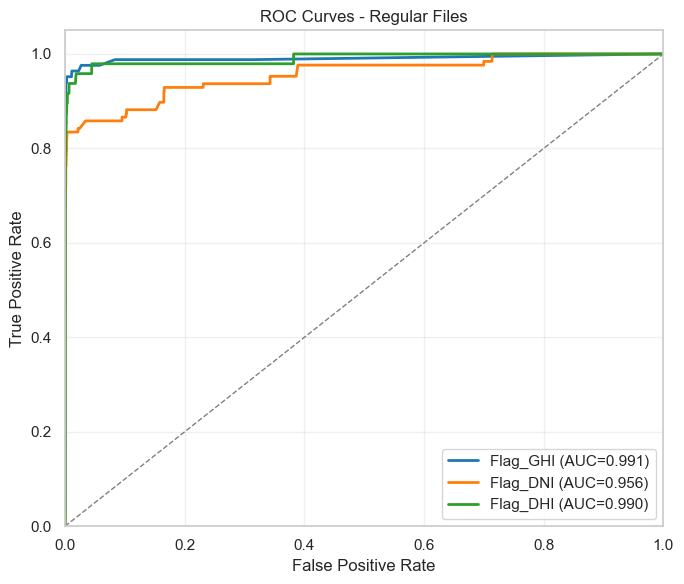

Saved plot: writeup\plot_target_confusion_matrices_Confusion_Matrices_-_Injected_Error_Files.png


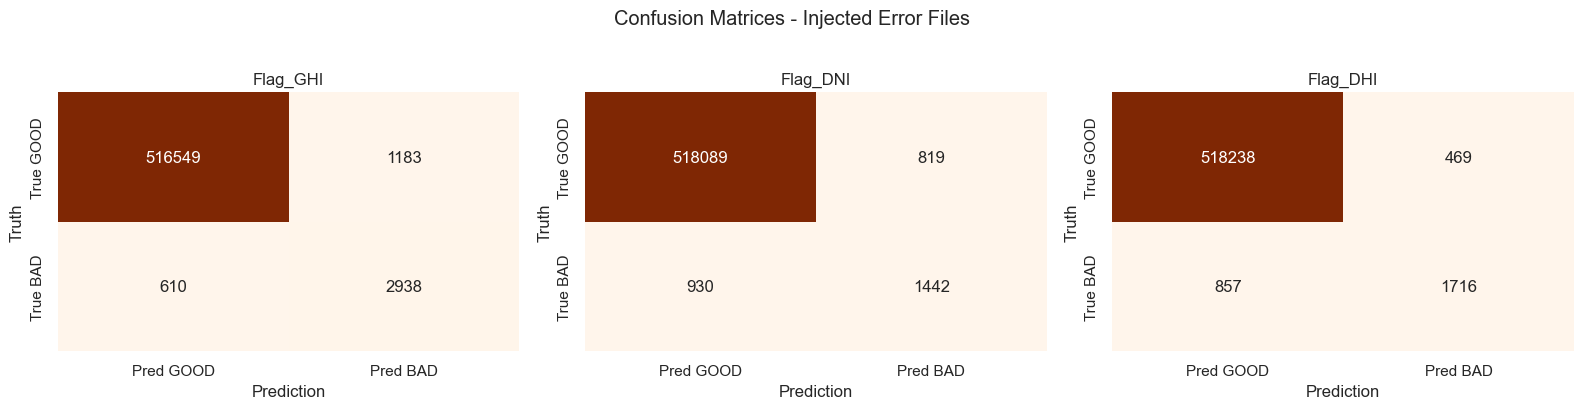

Saved plot: writeup\plot_target_roc_curves_ROC_Curves_-_Injected_Error_Files.png


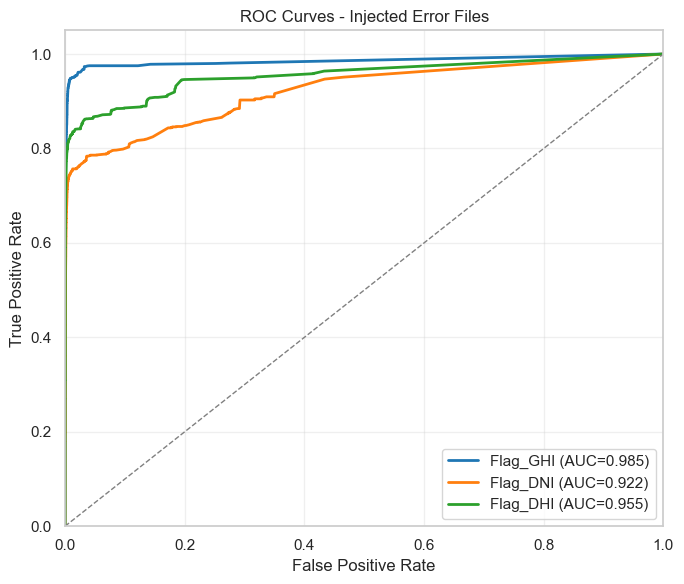

In [7]:
plot_target_confusion_matrices(all_results_regular, "Confusion Matrices - Regular Files", cmap="Blues")
# plot_disagreement_confusion_matrices(all_results_regular, "Regular Files")
# plot_target_pr_curves(all_results_regular, "Precision-Recall Curves - Regular Files (Better for imbalanced data)")
plot_target_roc_curves(all_results_regular, "ROC Curves - Regular Files")

if not all_results_injected.empty:
    plot_target_confusion_matrices(all_results_injected, "Confusion Matrices - Injected Error Files", cmap="Oranges")
    # plot_disagreement_confusion_matrices(all_results_injected, "Injected Error Files")
    # plot_target_pr_curves(all_results_injected, "Precision-Recall Curves - Injected Error Files")
    plot_target_roc_curves(all_results_injected, "ROC Curves - Injected Error Files")

## Time-Series Diagnostics

Saved plot: writeup\plot_hourly_bad_counts_injected_multiplot.png


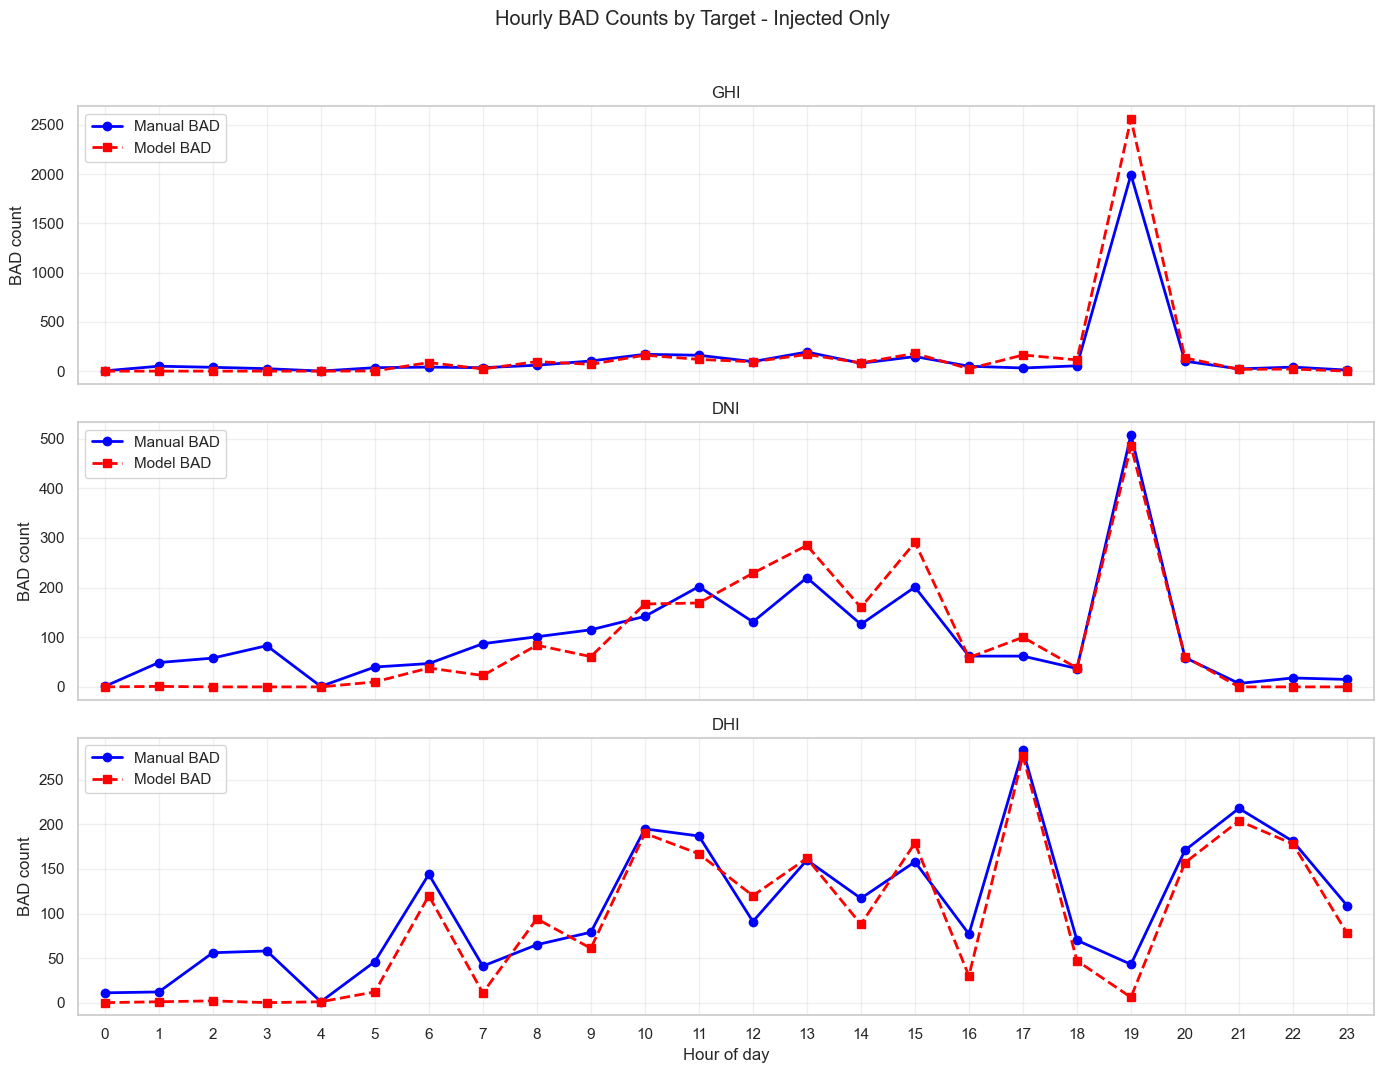

Saved plot: writeup\plot_monthly_bad_counts_injected_multiplot.png


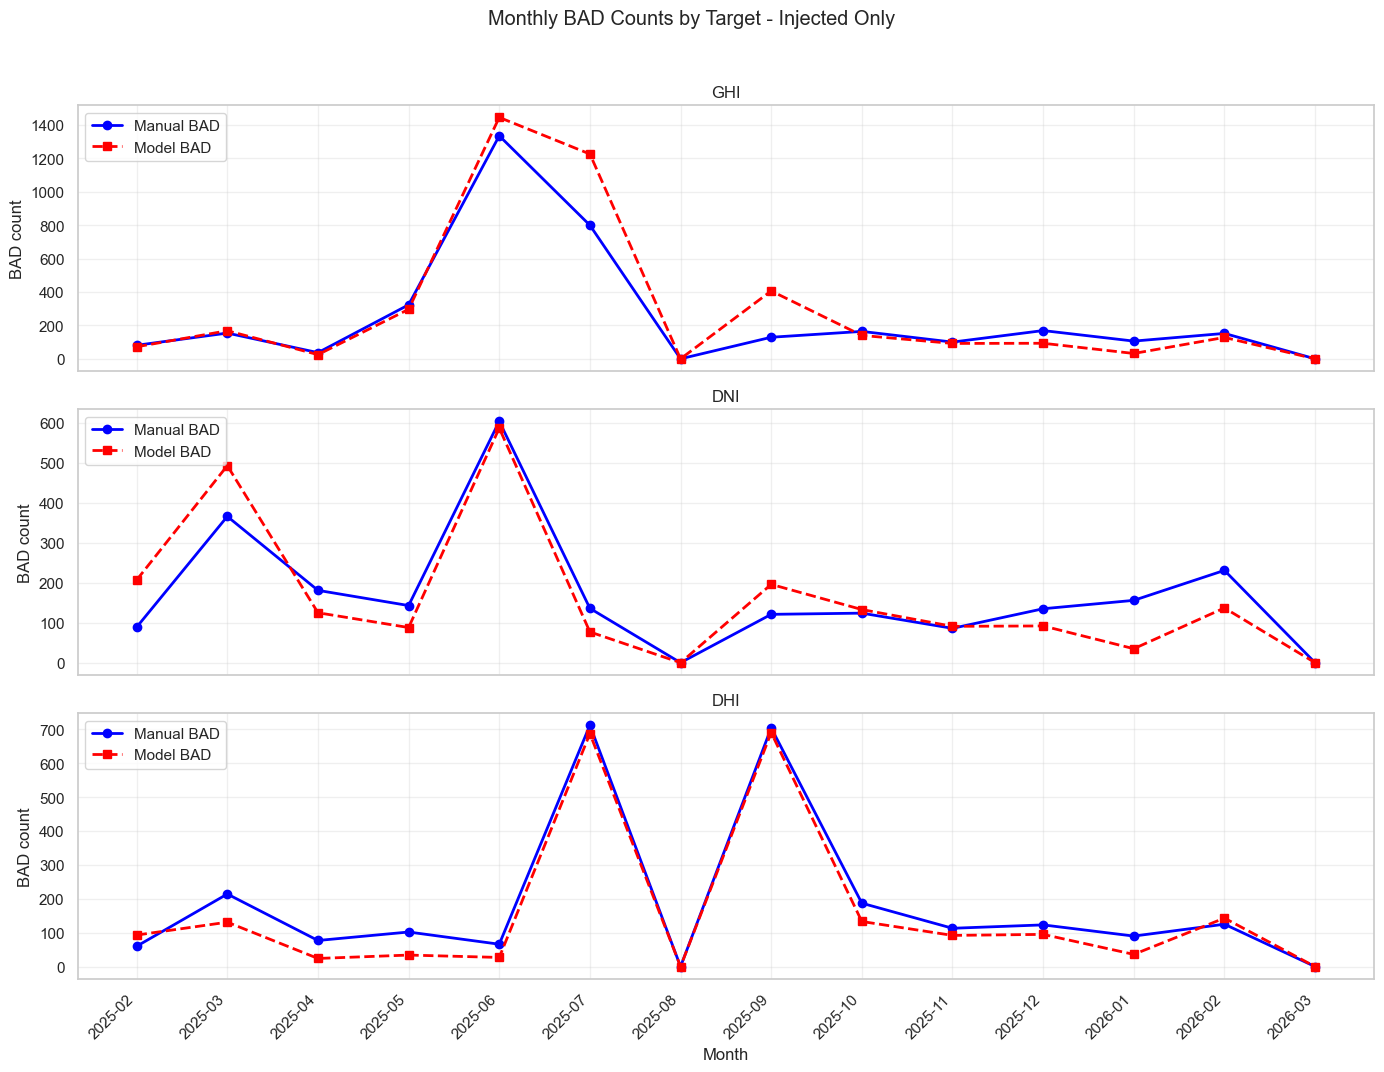

In [8]:
plot_hourly_bad_counts_comparison(df_injected, all_results_injected)
plot_monthly_bad_counts_comparison(df_injected, all_results_injected)

Saved plot: writeup\plot_daily_bad_counts.png


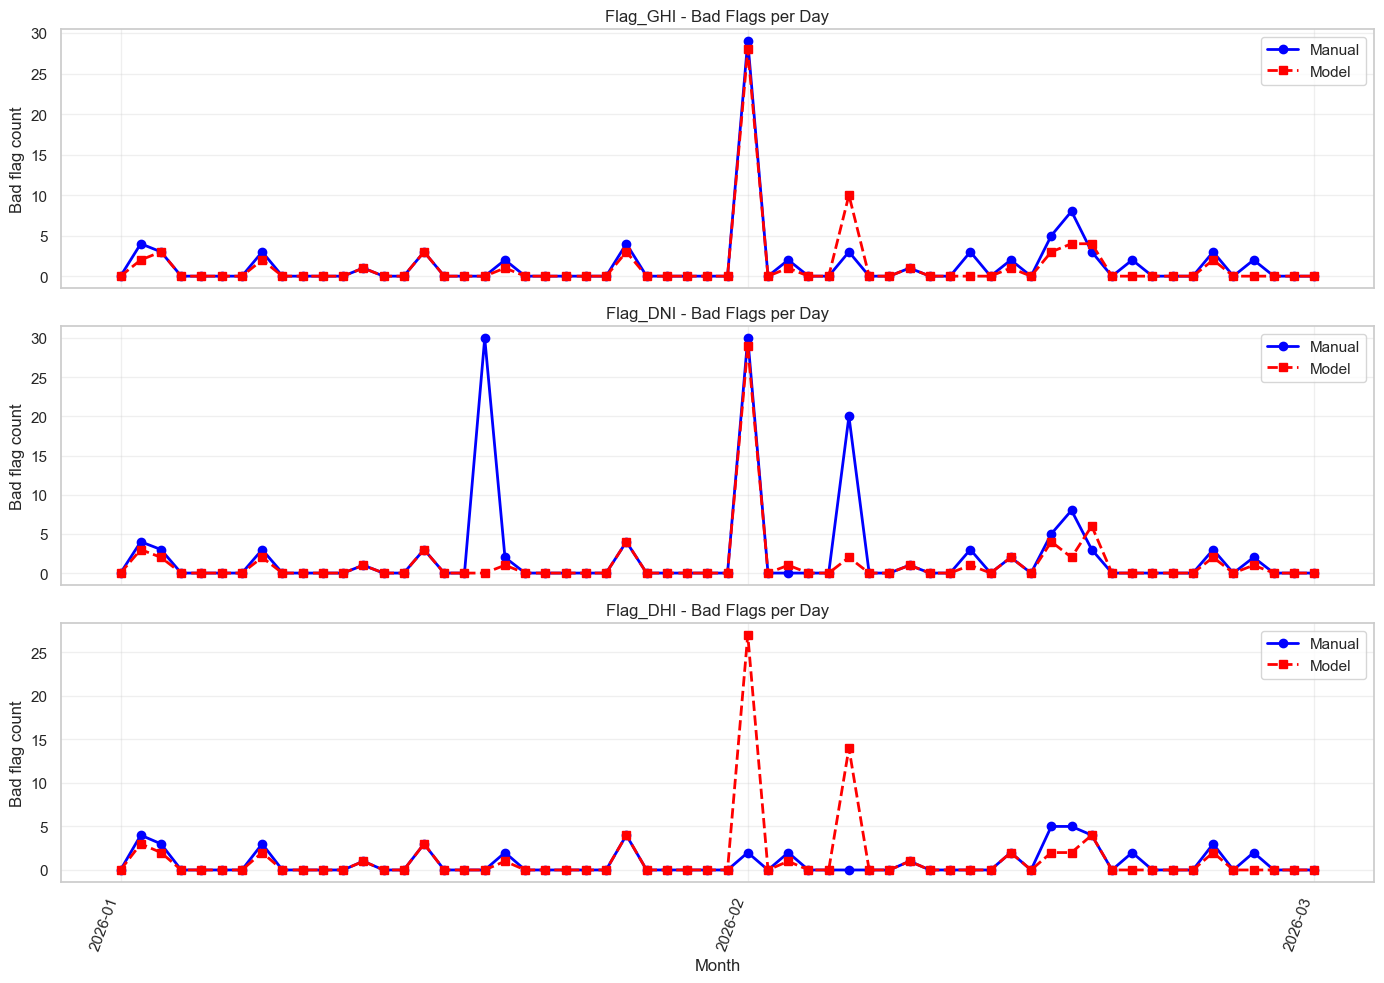

Saved plot: writeup\plot_daily_bad_counts.png


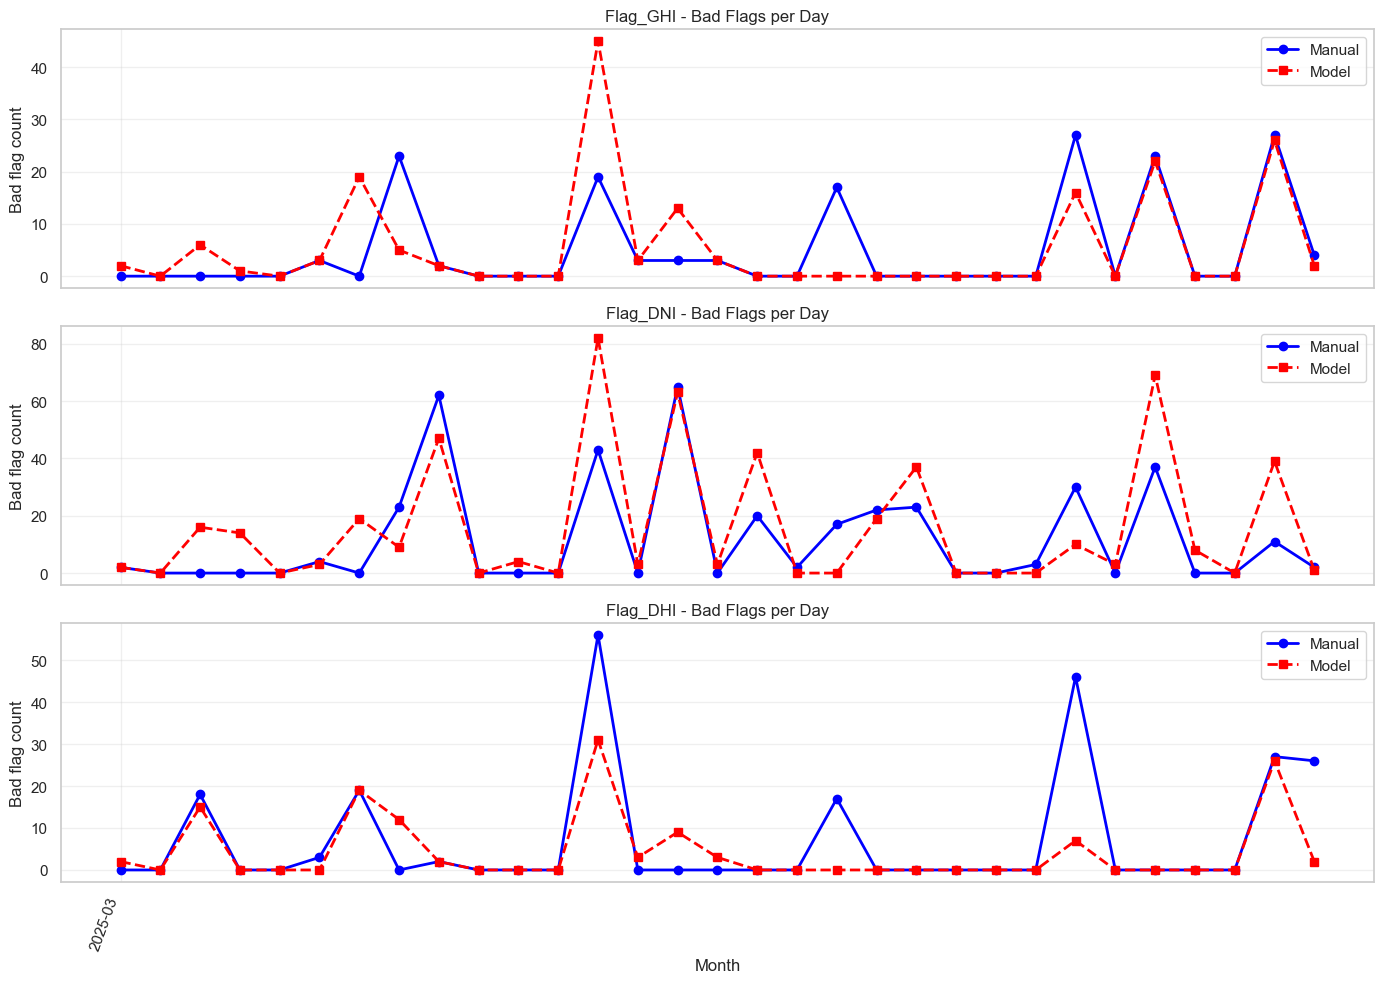

Saved plot: writeup\plot_focus_window_2026-02-01_2026-02-01_Window_Regular_Files.png


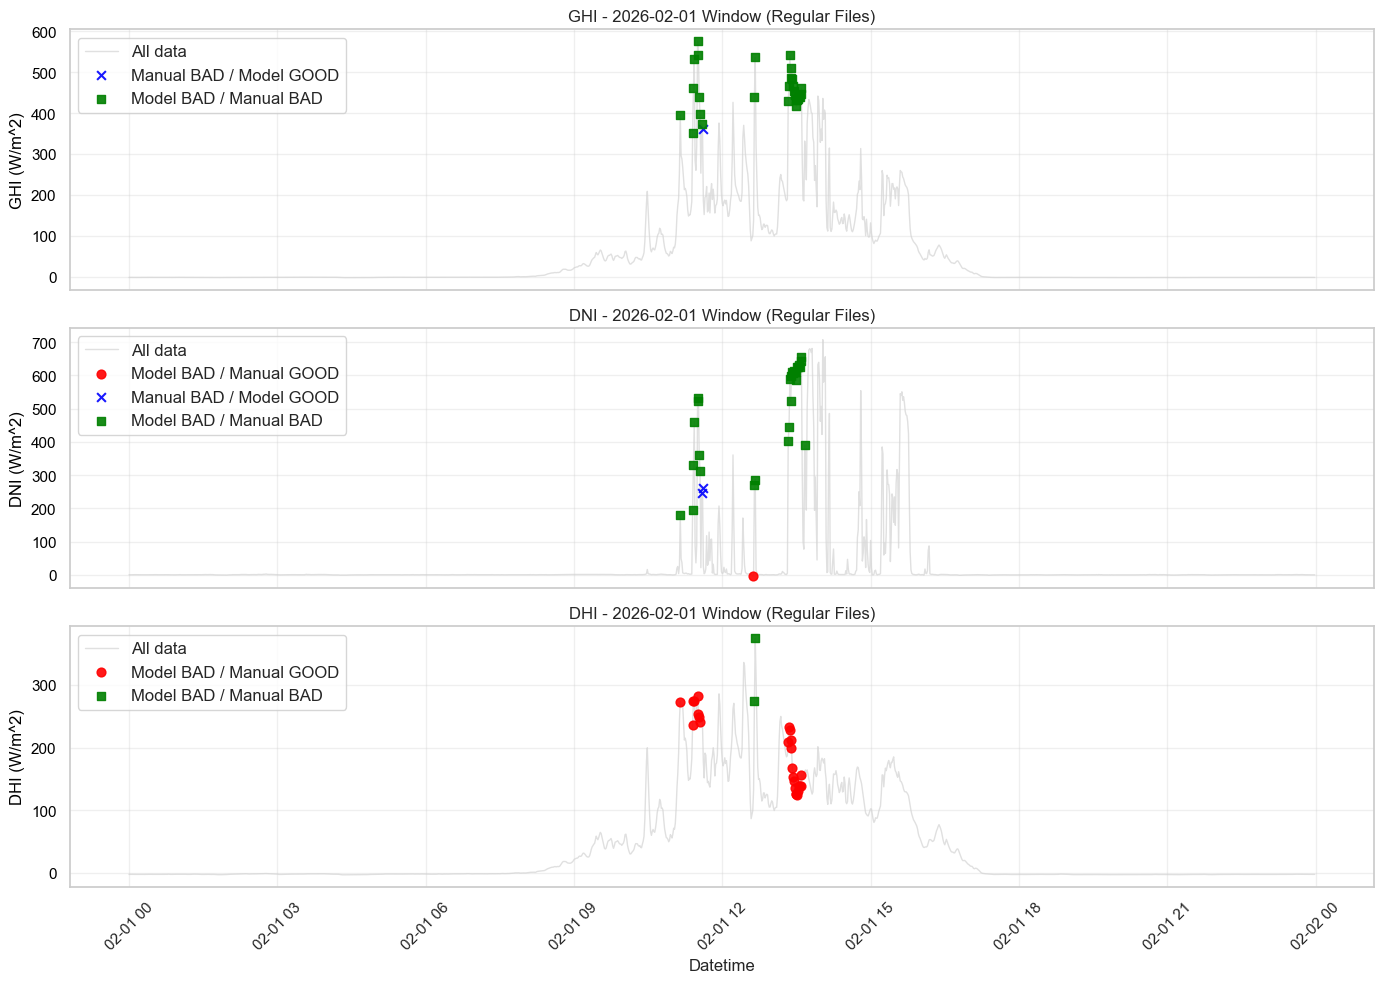

Saved plot: writeup\plot_focus_window_2026-02-06_2026-02-06_Window_Regular_Files.png


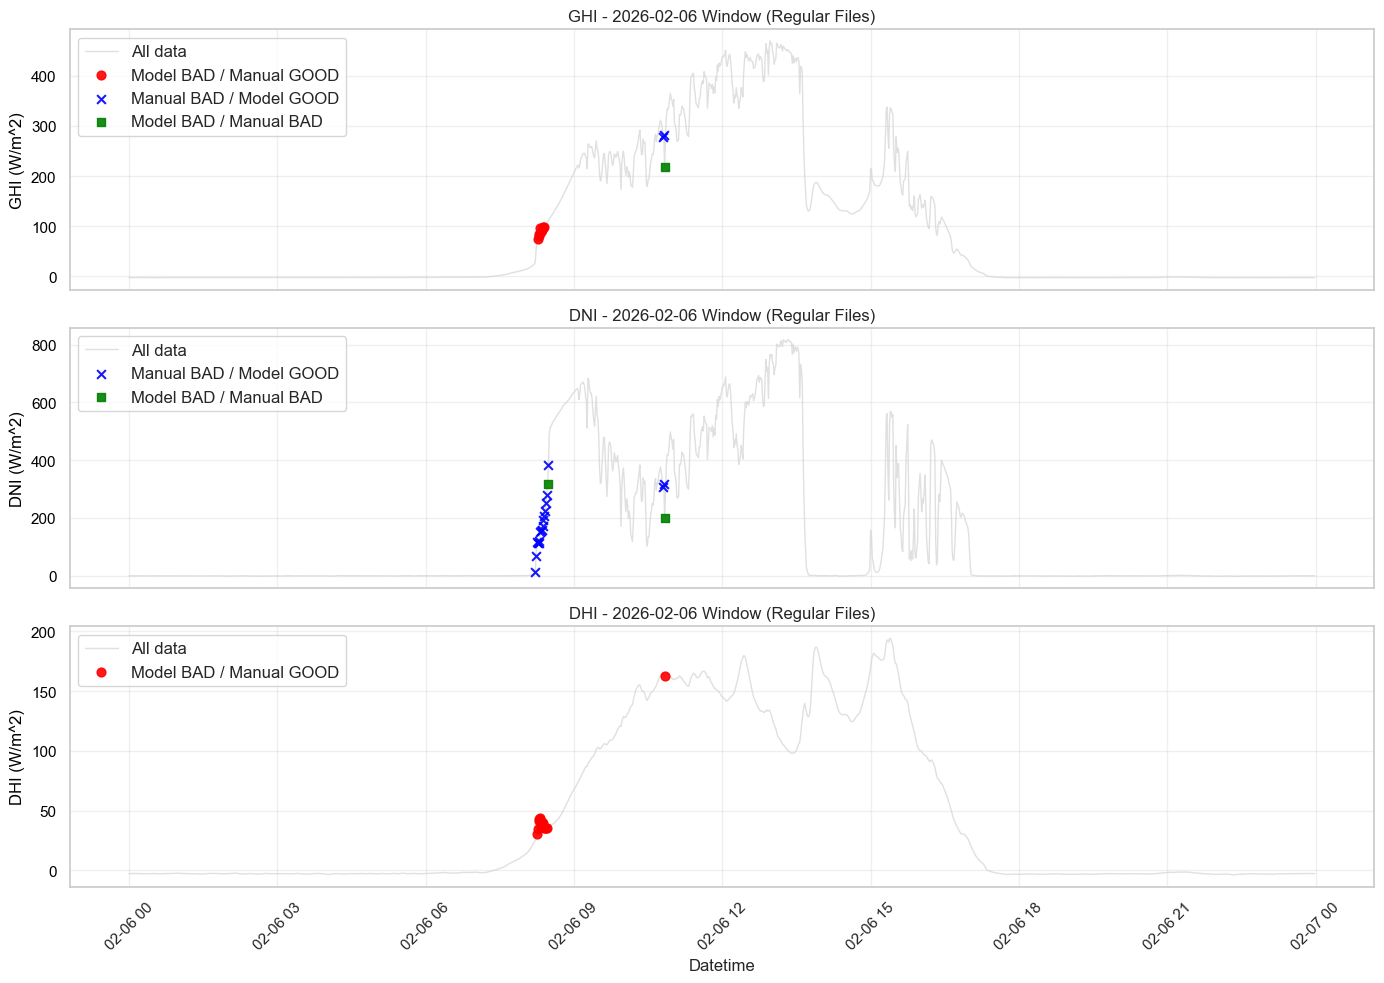

In [9]:
plot_daily_bad_counts(df_regular, all_results_regular)

if not df_injected.empty and not all_results_injected.empty:
    # Plot daily bad counts for injected error data (March 2025)
    injected_march_2025 = df_injected[
        (df_injected[TS_COL] >= "2025-03-01")
        & (df_injected[TS_COL] < "2025-04-01")
    ].copy()

    injected_results_march_2025 = all_results_injected[
        (all_results_injected["ts"] >= "2025-03-01")
        & (all_results_injected["ts"] < "2025-04-01")
    ].copy()

    if not injected_march_2025.empty:
        plot_daily_bad_counts(injected_march_2025, injected_results_march_2025)
    else:
        print("No injected error data available for March 2025.")

focus_windows = [
    # ("2026-01-19", "2026-01-20"),
    ("2026-02-01", "2026-02-02"),
    ("2026-02-06", "2026-02-07"),
    # ("2026-02-17", "2026-02-18"),
]

if TS_COL in df_regular.columns:
    df_regular = df_regular.copy()
    df_regular[TS_COL] = pd.to_datetime(df_regular[TS_COL], errors="coerce")
    df_regular["day"] = df_regular[TS_COL].dt.floor("D")

for start_ts, end_ts in focus_windows:
    statuses = ["model_only_bad", "manual_only_bad", "match_bad"]
    day_points = all_results_regular[
        (all_results_regular["ts"] >= start_ts)
        & (all_results_regular["ts"] < end_ts)
        & (all_results_regular["status"].isin(statuses))
    ].copy()

    day_raw = df_regular[
        (df_regular["day"] >= start_ts)
        & (df_regular["day"] < end_ts)
    ].copy()
    plot_focus_window(day_raw, day_points, start_ts, f"{start_ts} Window (Regular Files)")

## Time-Series-Specific Overall Model Evaluation

This section evaluates only the full model predictions against manual QC labels using time-series-aware diagnostics:

1. Calibration quality for BAD probabilities (Brier score and ECE)
2. Temporal clustering of errors (lag autocorrelation and month-hour heatmaps)
3. Detection latency around manual state transitions
4. Seasonal and diurnal robustness via rolling metrics

Rows in time-series evaluation frame: 1,314,374


,ts,target,current_flag,predicted_flag,p_bad,error
0,2025-02-02 12:13:00,Flag_DHI,99.0,99,0.774078,0
1,2025-02-06 09:41:00,Flag_DHI,99.0,99,0.856899,0
2,2025-02-06 09:42:00,Flag_DHI,99.0,99,0.857519,0
3,2025-02-06 09:43:00,Flag_DHI,99.0,99,0.856870,0
4,2025-02-06 09:44:00,Flag_DHI,99.0,99,0.857778,0
5,2025-02-06 09:45:00,Flag_DHI,99.0,99,0.858416,0
6,2025-02-06 09:46:00,Flag_DHI,99.0,99,0.857499,0
7,2025-02-06 09:47:00,Flag_DHI,99.0,99,0.857496,0
8,2025-02-06 09:48:00,Flag_DHI,99.0,99,0.857493,0
9,2025-02-06 09:49:00,Flag_DHI,99.0,99,0.856851,0



=== Calibration (BAD class) ===


,target,n,brier,ece,avg_p_bad,base_bad_rate
0,Flag_DHI,428560,0.002411,0.003338,0.008788,0.006004
1,Flag_DNI,427156,0.002631,0.003021,0.007381,0.005553
2,Flag_GHI,458658,0.001389,0.000770,0.007514,0.007736


Saved plot: writeup\plot_calibration_curves_Reliability_Curve_-_Overall_Model_BAD_class.png


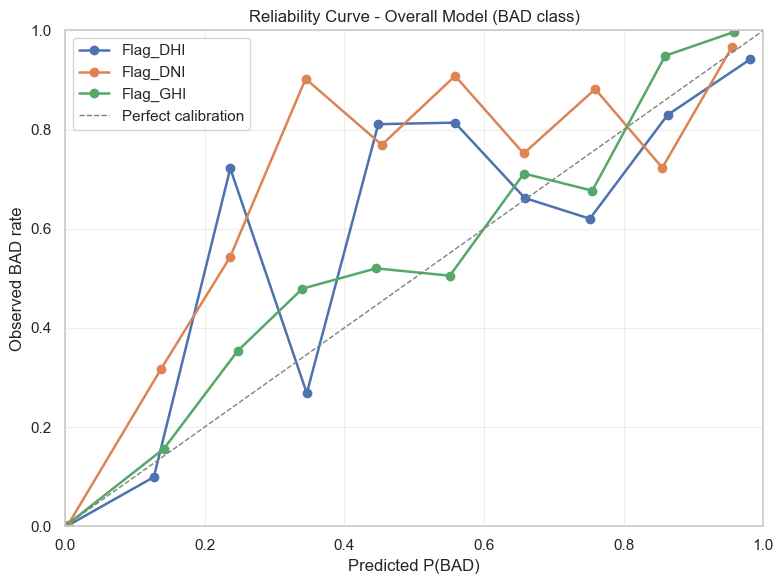


=== Error Clustering ===
Saved plot: writeup\plot_error_rate_heatmap.png


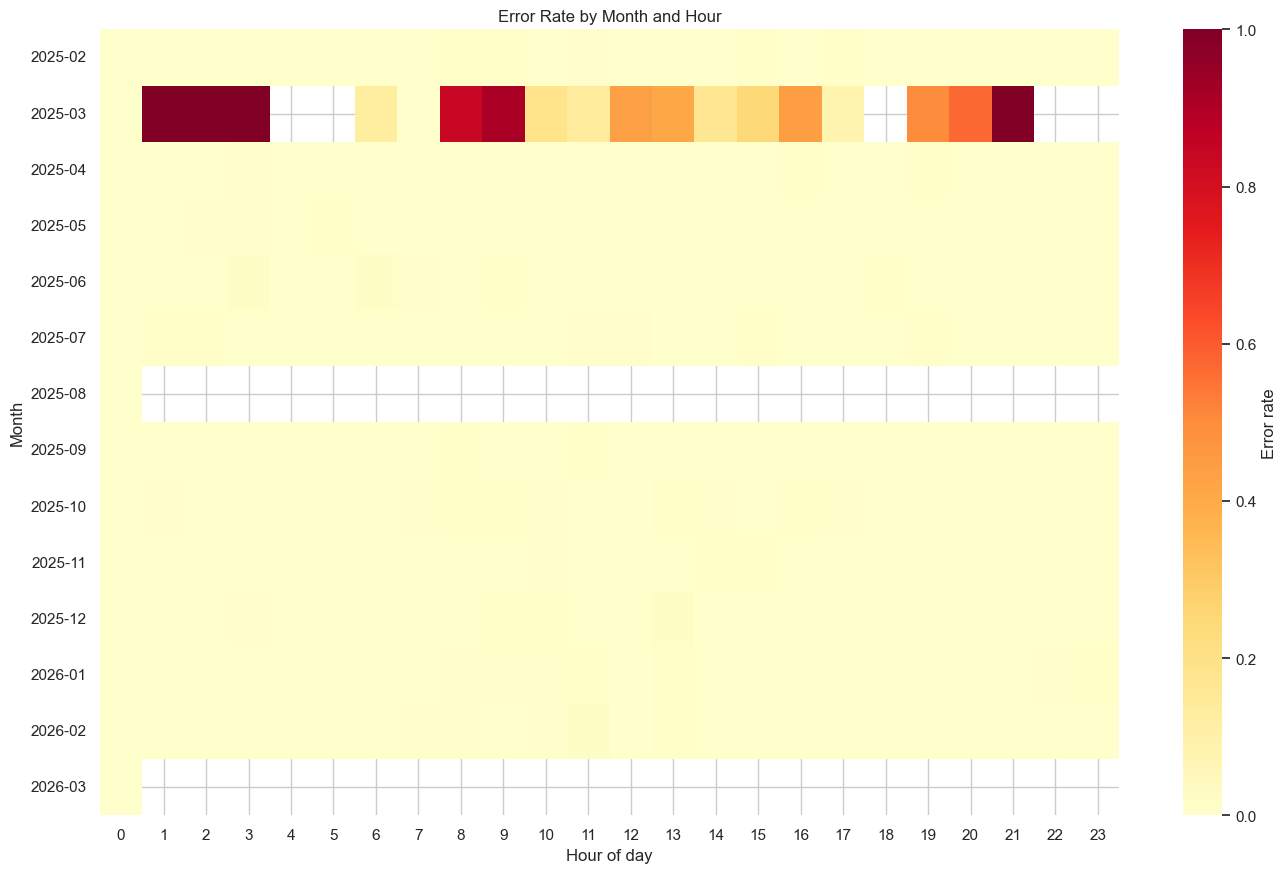


=== Detection Latency Around Manual Transitions ===


,target,episodes,detected_episodes,detection_rate,median_lag_h,p90_lag_h
0,Flag_DHI,199,140,0.703518,0.0,9.19
1,Flag_DNI,252,194,0.769841,0.0,9.74
2,Flag_GHI,286,244,0.853147,0.0,7.00


,target,episodes,early_detected,early_recall
0,Flag_DHI,199,113,0.567839
1,Flag_DNI,252,160,0.634921
2,Flag_GHI,286,210,0.734266


Saved plot: writeup\plot_detection_lag_distribution.png


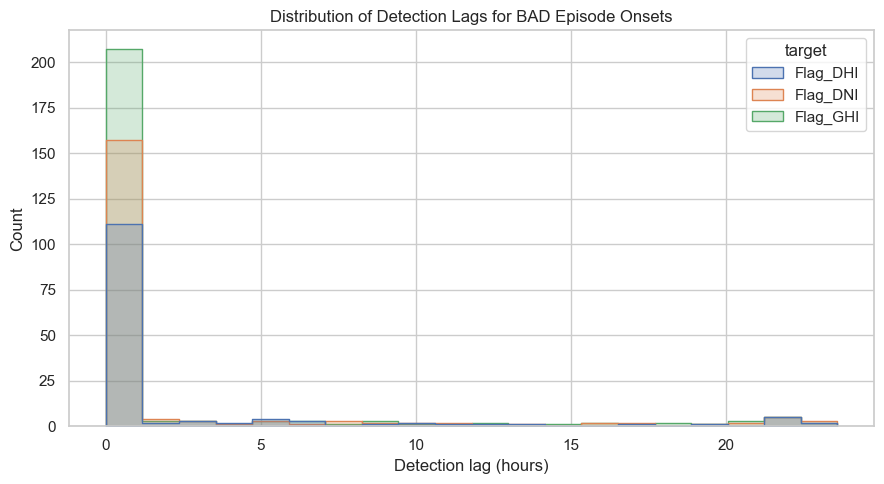

In [10]:
ts_eval_injected = build_ts_eval_frame(comparison_results_injected, TARGETS)

if ts_eval_injected.empty:
    print("No injected evaluation rows available for time-series-specific analysis.")
else:
    print(f"Rows in time-series evaluation frame: {len(ts_eval_injected):,}")
    display(ts_eval_injected[["ts", "target", "current_flag", "predicted_flag", "p_bad", "error"]].head(10))

    print("\n=== Calibration (BAD class) ===")
    calibration_metrics_df, calibration_curve_df = compute_calibration_stats(ts_eval_injected, n_bins=10)
    display(calibration_metrics_df)
    plot_calibration_curves(calibration_curve_df, "Reliability Curve - Overall Model (BAD class)")

    print("\n=== Error Clustering ===")
    # autocorr_df = compute_error_autocorrelation(ts_eval_injected, lag_hours=(1, 6, 24))
    # display(autocorr_df)
    # plot_error_autocorrelation(autocorr_df, "Error Autocorrelation by Lag (Overall Model)")
    plot_error_rate_heatmap(ts_eval_injected)

    print("\n=== Detection Latency Around Manual Transitions ===")
    lag_events_df = compute_detection_lags(ts_eval_injected, max_lookahead_hours=24)
    lag_summary_df = summarize_detection_lags(lag_events_df)
    early_recall_df = compute_bad_episode_early_recall(ts_eval_injected, horizon_hours=2)
    display(lag_summary_df)
    display(early_recall_df)
    plot_detection_lag_distribution(lag_events_df)